In [11]:
import matplotlib.pylab as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA


def heat_map(dataset, y_test, y_pred):

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=dataset.target_names,
        yticklabels=dataset.target_names
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")

    plt.show()


def model_with_pca_with_crossvalidation(
    dataset,
    model,
    n_componetPCA
):

    x = dataset.data
    y = dataset.target

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    f1_scores = []
    accuracies = []

    # Guarda as previsões do último fold
    ultimo_y_test = None
    ultimo_y_pred = None

    for fold, (train_index, test_index) in enumerate(
        skf.split(x, y), 1
    ):

        X_train = x[train_index]
        X_test = x[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        # -------------------------
        # NORMALIZAÇÃO
        # -------------------------

        scaler = StandardScaler()

        X_train_normalizado = scaler.fit_transform(X_train)
        X_test_normalizado = scaler.transform(X_test)

        # -------------------------
        # PCA
        # -------------------------

        pca = PCA(
            n_components=n_componetPCA
        )

        X_train_pca = pca.fit_transform(
            X_train_normalizado
        )

        X_test_pca = pca.transform(
            X_test_normalizado
        )


        model.fit(
            X_train_pca,
            y_train
        )

        y_pred = model.predict(
            X_test_pca
        )


        f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        ) * 100

        acc = accuracy_score(
            y_test,
            y_pred
        ) * 100

        f1_scores.append(f1)
        accuracies.append(acc)

        ultimo_y_test = y_test
        ultimo_y_pred = y_pred


    heat_map(
        dataset=dataset,
        y_test=ultimo_y_test,
        y_pred=ultimo_y_pred
    )


    print("\n-----------------------------")

    print(
        f"F1 médio: "
        f"{np.mean(f1_scores):.2f}%"
    )


    print(
        f"Accuracy média: "
        f"{np.mean(accuracies):.2f}%"
    )


def model_without_pca_with_crossvalidation(
    dataset,
    model
):

    x = dataset.data
    y = dataset.target

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    f1_scores = []
    accuracies = []

    ultimo_y_test = None
    ultimo_y_pred = None

    for fold, (train_index, test_index) in enumerate(
        skf.split(x, y), 1
    ):

        X_train = x[train_index]
        X_test = x[test_index]

        y_train = y[train_index]
        y_test = y[test_index]


        scaler = StandardScaler()

        X_train_normalizado = scaler.fit_transform(
            X_train
        )

        X_test_normalizado = scaler.transform(
            X_test
        )


        model.fit(
            X_train_normalizado,
            y_train
        )

        y_pred = model.predict(
            X_test_normalizado
        )


        f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        ) * 100

        acc = accuracy_score(
            y_test,
            y_pred
        ) * 100

        
        f1_scores.append(f1)
        accuracies.append(acc)

        ultimo_y_test = y_test
        ultimo_y_pred = y_pred



    heat_map(
        dataset=dataset,
        y_test=ultimo_y_test,
        y_pred=ultimo_y_pred
    )


    print("\n-----------------------------")

    print(
        f"F1 médio: "
        f"{np.mean(f1_scores):.2f}%"
    )


    print(
        f"Accuracy média: "
        f"{np.mean(accuracies):.2f}%"
    )

COM PCA


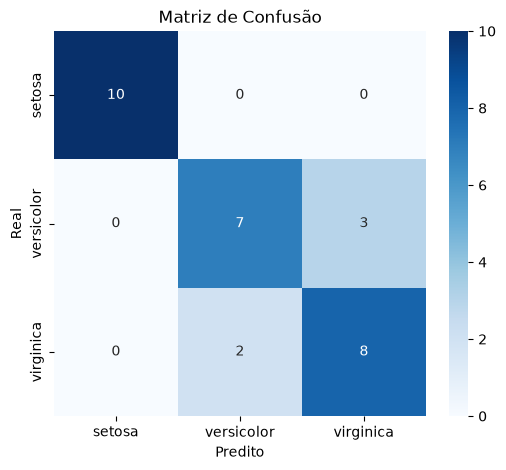


-----------------------------
F1 médio: 91.97%
Accuracy média: 92.00%
----------------------------------------------------
SEM PCA


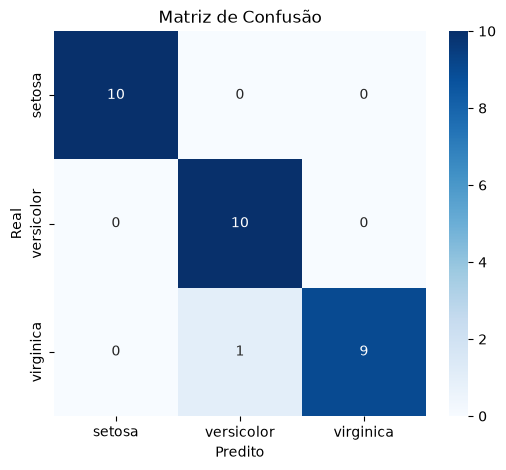


-----------------------------
F1 médio: 97.33%
Accuracy média: 97.33%


In [25]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors= 5)
dataset = load_iris()

print("COM PCA")
model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=2)
print("----------------------------------------------------")
print("SEM PCA")
model_without_pca_with_crossvalidation(dataset=dataset,model=model)

COM PCA


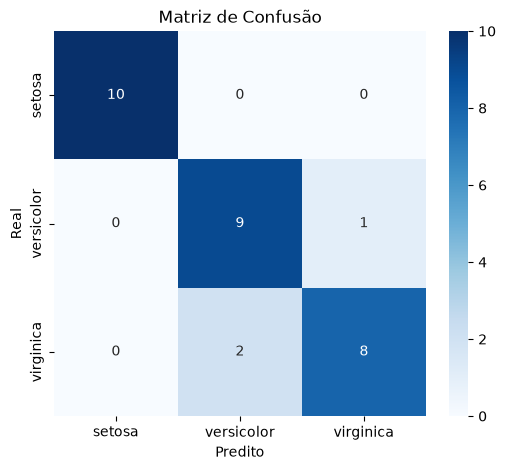


-----------------------------
F1 médio: 95.99%
Accuracy média: 96.00%
----------------------------------------------------
SEM PCA


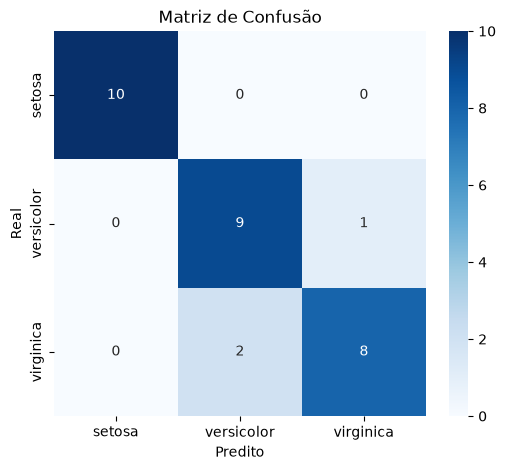


-----------------------------
F1 médio: 94.64%
Accuracy média: 94.67%


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

dataset = load_iris()
model = RandomForestClassifier(random_state=42)
print("COM PCA")
model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=4)
print("----------------------------------------------------")
print("SEM PCA")
model_without_pca_with_crossvalidation(dataset=dataset,model=model)


COM PCA


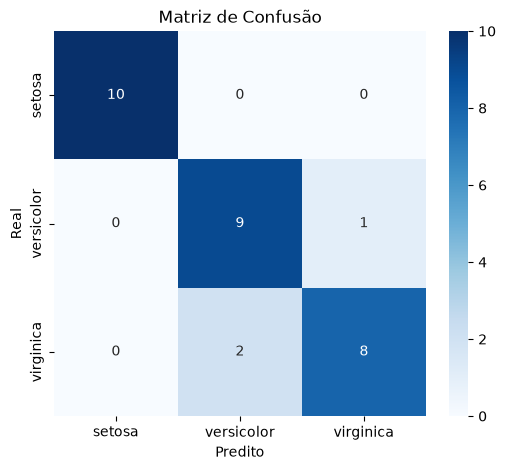


-----------------------------
F1 médio: 95.32%
Accuracy média: 95.33%
----------------------------------------------------
SEM PCA


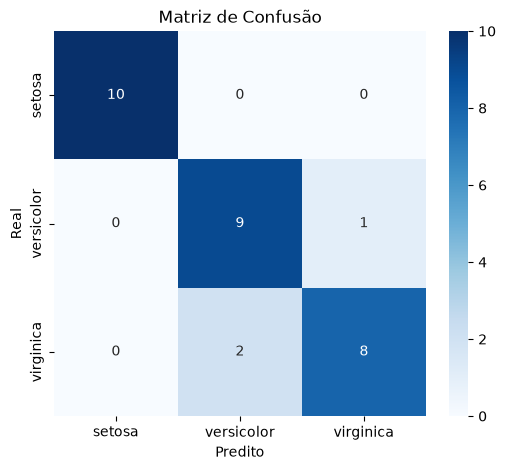


-----------------------------
F1 médio: 95.32%
Accuracy média: 95.33%


In [36]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100000)
print("COM PCA")
model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=4)
print("----------------------------------------------------")
print("SEM PCA")
model_without_pca_with_crossvalidation(dataset=dataset,model=model)

COM PCA


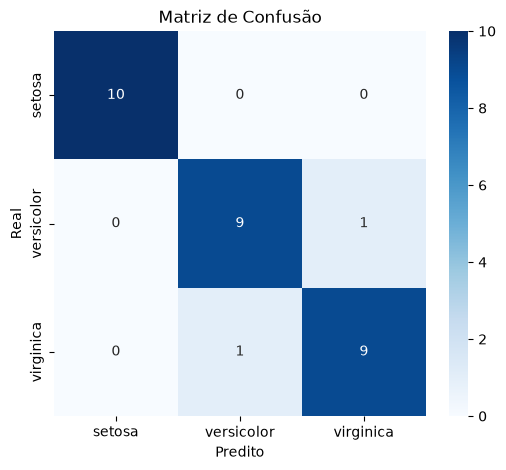


-----------------------------
F1 médio: 96.66%
Accuracy média: 96.67%
----------------------------------------------------
SEM PCA


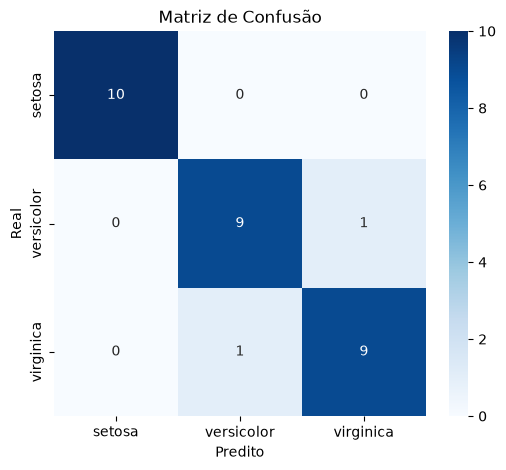


-----------------------------
F1 médio: 95.99%
Accuracy média: 96.00%


In [41]:
from sklearn.svm import SVC
from sklearn.datasets import load_iris

model = SVC()
dataset = load_iris()
print("COM PCA")
model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=3)
print("----------------------------------------------------")
print("SEM PCA")
model_without_pca_with_crossvalidation(dataset=dataset,model=model)

In [46]:
for i in range(1,4):
    print(i)

1
2
3


In [ ]:
def best_component():
    percents= []
    for i in range(1,len(dataset.feature_names) + 1):
        a = model_with_pca_with_crossvalidation(dataset=dataset,model=model, n_componetPCA=i)
        percents.append(("valor",i))


4